In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/CNN_Project", exist_ok=True)

print("Project Folder Created")

Project Folder Created


#Import Libraries

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
print("All imports successful")

All imports successful


#Data Preparation and Exploration

In [ ]:
(X_train, y_train),(X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X_train,y_train, test_size=0.1, random_state=101)

In [ ]:
X_train.shape, y_train.shape

((45000, 32, 32, 3), (45000, 1))

In [ ]:
X_valid.shape, y_valid.shape

((5000, 32, 32, 3), (5000, 1))

In [ ]:
X_test.shape, y_test.shape

((10000, 32, 32, 3), (10000, 1))

In [ ]:
class_names = ['airplane', 'automobile', 'bird','cat','deer','dog','frog','horse','ship','truck']

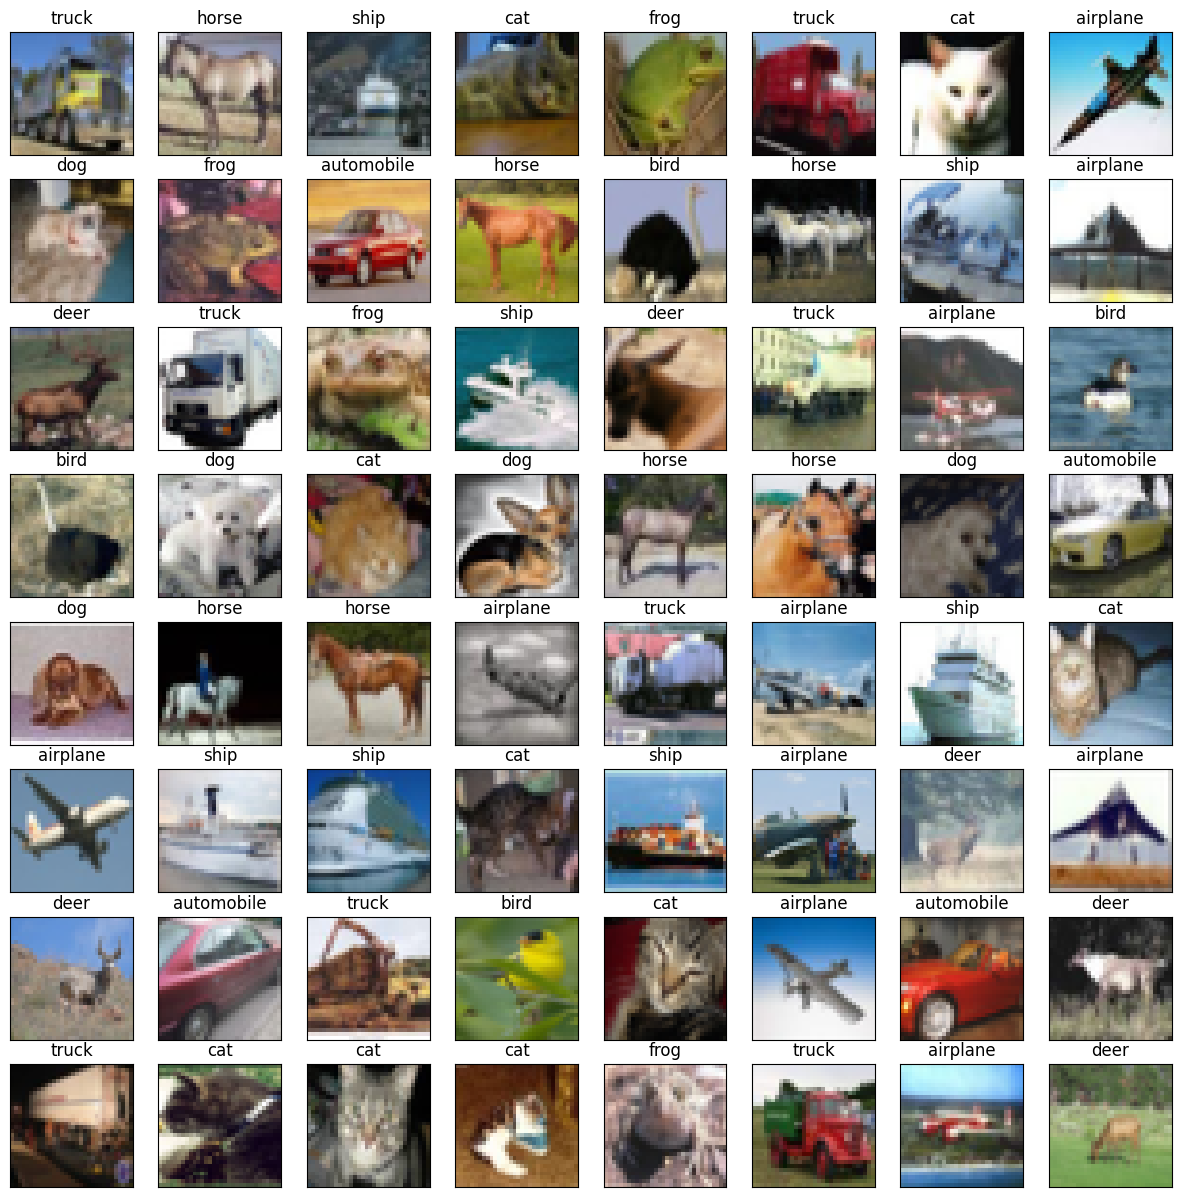

In [ ]:
plt.figure(figsize=(15,15))
for i in range(64):
  plt.subplot(8,8,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]])

plt.show()

# Data Preprocssing

1. Normalisation of images
2. One hot encoding of Labels
3. Data Augmentation

#### Normalisation

In [ ]:
#Converting pixel values to float32

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_valid = X_valid.astype('float32')

#Calculate the mean and std of training images
mean = np.mean(X_train)
std = np.std(X_train)

#Normalize the data
X_train = (X_train-mean)/(std+.00000001)
X_test = (X_test-mean)/(std+.00000001)
X_valid = (X_valid-mean)/(std+.00000001)

#### One Hot Encoding of Labels


In [ ]:
y_train = to_categorical(y_train,10)
y_valid = to_categorical(y_valid,10)
y_test = to_categorical(y_test,10)

#### Data Augmentation

In [ ]:
data_generator = ImageDataGenerator(
    rotation_range = 15, #rotate images by up to 15 degree
    width_shift_range = .12, #shift images horizontally by upto 12% of width
    height_shift_range = 0.12,
    horizontal_flip =True,
    zoom_range = 0.1,
    brightness_range = [0.9,1.1],
    shear_range = 10, #Shear intesity (share angle in anti clockwise direction),
    channel_shift_range = 0.1
)

## Model

In [ ]:
model = Sequential()

weight_decay = 0.0001 #weight decay for l2 regularization

model.add(Conv2D(filters=32, kernel_size = (3,3), padding='same', activation = 'relu', kernel_regularizer =l2(weight_decay), input_shape = X_train.shape[1:]))
model.add(BatchNormalization())

model.add(Conv2D(filters=32, kernel_size = (3,3), padding='same', activation = 'relu', kernel_regularizer =l2(weight_decay)))
model.add(BatchNormalization())

#Add first max pooling layer with pool size of 2*2
model.add(MaxPooling2D(pool_size=(2,2)))
#Add dropout layer with 0.2 dropout rate
model.add(Dropout(rate=0.2))


#Add the third and fourth Conv layers
model.add(Conv2D(filters=64, kernel_size = (3,3), padding='same', activation = 'relu', kernel_regularizer =l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters=64, kernel_size = (3,3), padding='same', activation = 'relu', kernel_regularizer =l2(weight_decay)))
model.add(BatchNormalization())

#Add 2nd max pooling layer with pool size of 2*2
model.add(MaxPooling2D(pool_size=(2,2)))
#Add dropout layer with 0.3 dropout rate
model.add(Dropout(rate=0.3))


model.add(Conv2D(filters=128, kernel_size = (3,3), padding='same', activation = 'relu', kernel_regularizer =l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters=128, kernel_size = (3,3), padding='same', activation = 'relu', kernel_regularizer =l2(weight_decay)))
model.add(BatchNormalization())

#Add 3rd max pooling layer with pool size of 2*2
model.add(MaxPooling2D(pool_size=(2,2)))
#Add dropout layer with 0.4 dropout rate
model.add(Dropout(rate=0.4))


model.add(Conv2D(filters=256, kernel_size = (3,3), padding='same', activation = 'relu', kernel_regularizer =l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters=256, kernel_size = (3,3), padding='same', activation = 'relu', kernel_regularizer =l2(weight_decay)))
model.add(BatchNormalization())


#Add 4th max pooling layer with pool size of 2*2
model.add(MaxPooling2D(pool_size=(2,2)))
#Add dropout layer with 0.5 dropout rate
model.add(Dropout(rate=0.5))


#Flatten the tensor output from the previous layer
model.add(Flatten())

#Add a fully connected layer with softmax activation function
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,186,346 (4.53 MB)

 Trainable params: 1,184,426 (4.52 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# Set the batch size
batch_size =64

epochs = 150 #instead of 150, run this for 300/400 epochs

optimizer = Adam(learning_rate=0.0005)

model.compile(optimizer = optimizer, loss = 'categorical_crossentropy', metrics = ['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience = 10, min_lr = .00001)

early_stopping = EarlyStopping(monitor = 'val_loss', patience = 40, restore_best_weights=True, verbose=1)

model.fit(data_generator.flow(X_train, y_train, batch_size=batch_size),
                              epochs = epochs,
                              validation_data = (X_valid, y_valid),
                              callbacks = [reduce_lr, early_stopping],
                              verbose=2)

Epoch 1/150
704/704 - 75s - 107ms/step - accuracy: 0.3350 - loss: 2.3507 - val_accuracy: 0.4190 - val_loss: 1.7514 - learning_rate: 5.0000e-04
Epoch 2/150
704/704 - 47s - 66ms/step - accuracy: 0.4622 - loss: 1.7531 - val_accuracy: 0.5318 - val_loss: 1.4985 - learning_rate: 5.0000e-04
Epoch 3/150
704/704 - 46s - 66ms/step - accuracy: 0.5303 - loss: 1.5027 - val_accuracy: 0.5658 - val_loss: 1.4032 - learning_rate: 5.0000e-04
Epoch 4/150
704/704 - 47s - 66ms/step - accuracy: 0.5700 - loss: 1.3688 - val_accuracy: 0.6042 - val_loss: 1.2430 - learning_rate: 5.0000e-04
Epoch 5/150
704/704 - 47s - 67ms/step - accuracy: 0.6085 - loss: 1.2481 - val_accuracy: 0.6474 - val_loss: 1.1903 - learning_rate: 5.0000e-04
Epoch 6/150
704/704 - 47s - 67ms/step - accuracy: 0.6410 - loss: 1.1546 - val_accuracy: 0.7034 - val_loss: 1.0089 - learning_rate: 5.0000e-04
Epoch 7/150
704/704 - 46s - 66ms/step - accuracy: 0.6695 - loss: 1.0640 - val_accuracy: 0.7064 - val_loss: 0.9885 - learning_rate: 5.0000e-04
Epoch

## Visualizing the Learning Curves

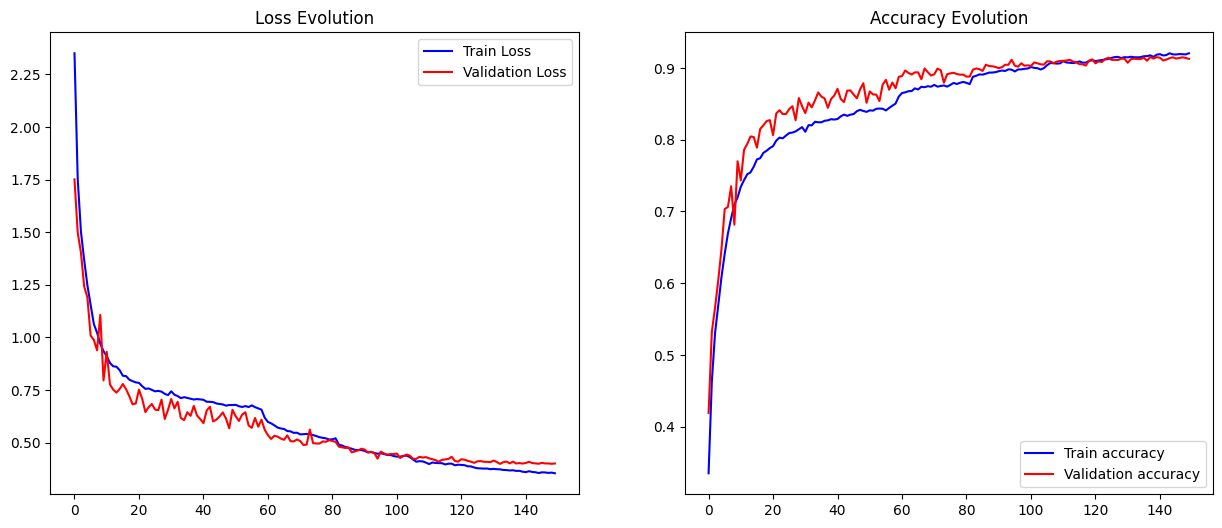

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.plot(model.history.history['loss'], label = 'Train Loss', color = 'blue')
plt.plot(model.history.history['val_loss'], label = 'Validation Loss', color = 'red')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(1,2,2)
plt.plot(model.history.history['accuracy'], label = 'Train accuracy', color = 'blue')
plt.plot(model.history.history['val_accuracy'], label = 'Validation accuracy', color = 'red')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

## Evaluating the Optimal Model on Test Data

In [ ]:
test_loss, test_acc = model.evaluate(X_test,y_test, verbose = 1)

print(f'Test Accuracy : {test_acc}\nTestLoss: {test_loss}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9025 - loss: 0.4396
Test Accuracy : 0.9024999737739563
TestLoss: 0.4395521581172943


# 1.Performance on an out of Dataset image

In [ ]:
url = 'https://naturealberta.ca/wp-content/uploads/2025/04/6.-Tree-Swallow-NICK-CARTER-1536x1340.jpg'
#'https://wildjolie.com/cdn/shop/articles/Do_Horses_Have_Horns.jpg?v=1741247407&width=1780'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

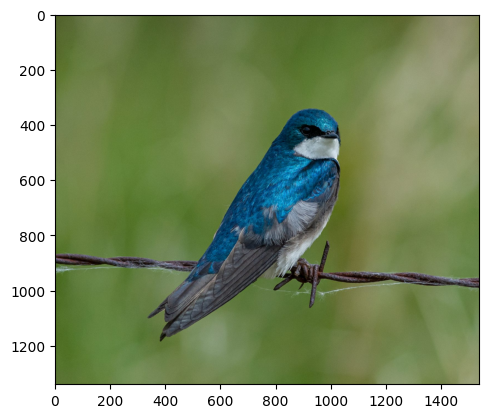

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image.shape

(1340, 1536, 3)

In [ ]:
image = cv2.resize(image, (32,32))

#normalize the image
image = (image-mean)/(std+0.000001)

#Add an exyra dimension because the model expects a batch of images
image = image.reshape((1,32,32,3))

In [ ]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
predict

array([[9.2168141e-04, 2.0914176e-06, 9.9838459e-01, 2.5327838e-04,
        1.1983841e-05, 3.1824798e-05, 3.3240879e-04, 1.5507414e-05,
        2.8418633e-06, 4.3745244e-05]], dtype=float32)

In [ ]:
print(f'The predicted class: {class_names[predict.argmax()]}')

The predicted class: bird


# 2.Performance on an out of Dataset image

In [ ]:
url = 'https://www.livemint.com/lm-img/img/2023/03/28/1600x900/2-0-1272577671-The-BMW-7-Series--1--0_1679601246762_1679987537331_1679987537331.jpg'
#'https://in.images.search.yahoo.com/search/images;_ylt=Awrx_4w3gylqmQIA2Qe7HAx.;_ylu=Y29sbwNzZzMEcG9zAzEEdnRpZAMEc2VjA3BpdnM-?p=automobile+images&fr2=piv-web&type=E210IN885G0&fr=mcafee#id=34&iurl=https%3A%2F%2Fwww.livemint.com%2Flm-img%2Fimg%2F2023%2F03%2F28%2F1600x900%2F2-0-1272577671-The-BMW-7-Series--1--0_1679601246762_1679987537331_1679987537331.jpg&action=click'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

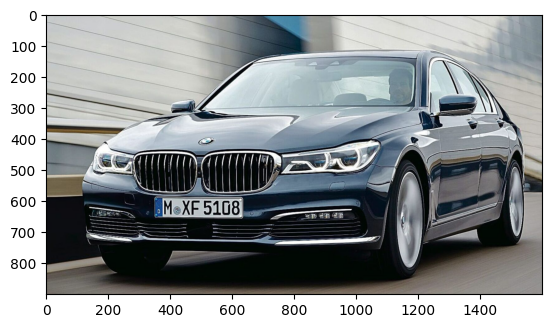

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image.shape

(900, 1600, 3)

In [ ]:
image = cv2.resize(image, (32,32))

#normalize the image
image = (image-mean)/(std+0.000001)

#Add an exyra dimension because the model expects a batch of images
image = image.reshape((1,32,32,3))

In [ ]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [ ]:
predict

array([[2.9252443e-04, 2.3110379e-01, 1.8740355e-03, 7.1205231e-03,
        3.3386808e-05, 1.5548594e-05, 1.5620911e-02, 5.6771863e-05,
        6.4467606e-03, 7.3743570e-01]], dtype=float32)

In [ ]:
print(f'The predicted class: {class_names[predict.argmax()]}')

The predicted class: truck


3.Performance on an out of Dataset image


In [ ]:
url = 'https://images5.alphacoders.com/340/340415.jpg'
#'https://in.images.search.yahoo.com/search/images;_ylt=AwrPrNDUiSlqapkPVW69HAx.;_ylu=c2VjA3NlYXJjaARzbGsDYnV0dG9u;_ylc=X1MDMjExNDcyMzAwNQRfcgMyBGZyA21jYWZlZQRmcjIDcDpzLHY6aSxtOnNiLXRvcARncHJpZANFeVpqTjFmalNCV3U2eUVnQjIwR19BBG5fcnNsdAMwBG5fc3VnZwMxMARvcmlnaW4DaW4uaW1hZ2VzLnNlYXJjaC55YWhvby5jb20EcG9zAzAEcHFzdHIDBHBxc3RybAMwBHFzdHJsAzExBHF1ZXJ5A2RlZXIlMjBpbWFnZXMEdF9zdG1wAzE3ODExMDcyNTA-?p=deer+images&fr=mcafee&fr2=p%3As%2Cv%3Ai%2Cm%3Asb-top&ei=UTF-8&x=wrt&type=E210IN885G0#id=17&iurl=https%3A%2F%2Fimages5.alphacoders.com%2F340%2F340415.jpg&action=click'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

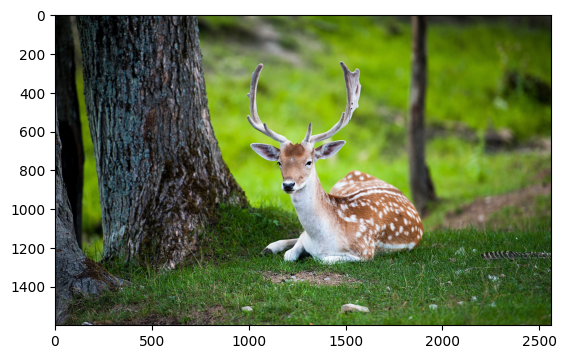

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image.shape

(1600, 2560, 3)

In [ ]:
image = cv2.resize(image, (32,32))

#normalize the image
image = (image-mean)/(std+0.000001)

#Add an exyra dimension because the model expects a batch of images
image = image.reshape((1,32,32,3))

In [ ]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [ ]:
predict

array([[2.0713342e-08, 3.2311743e-08, 9.3024290e-01, 9.1439653e-03,
        4.3904867e-02, 1.7563845e-05, 1.6672848e-02, 1.1521003e-05,
        1.2103351e-07, 6.1731448e-06]], dtype=float32)

In [ ]:
print(f'The predicted class: {class_names[predict.argmax()]}')

The predicted class: bird


In [ ]:
print(y_test.shape)
print(y_train.shape)

(10000, 10)
(45000, 10)


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot labels back to class numbers
y_true = np.argmax(y_test, axis=1)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred_classes.shape)

print(classification_report(y_true, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
y_true shape: (10000,)
y_pred shape: (10000,)
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      1000
           1       0.95      0.95      0.95      1000
           2       0.91      0.87      0.89      1000
           3       0.85      0.75      0.80      1000
           4       0.89      0.91      0.90      1000
           5       0.88      0.81      0.85      1000
           6       0.85      0.97      0.90      1000
           7       0.93      0.95      0.94      1000
           8       0.94      0.95      0.94      1000
           9       0.90      0.96      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 90.25%
Test Loss     : 0.4396


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<Figure size 1000x800 with 0 Axes>

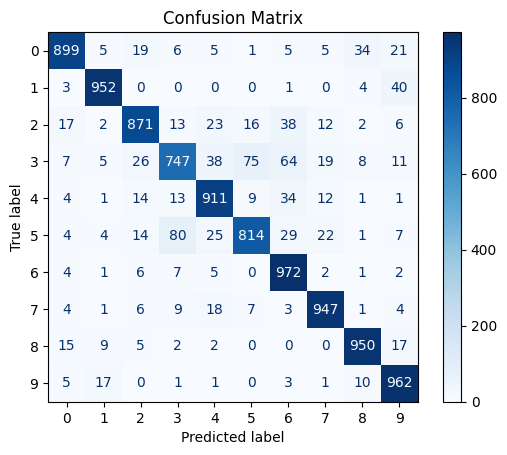

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import os

model.save("cnn_cifar10.h5")

model_size = os.path.getsize("cnn_cifar10.h5")/(1024*1024)

print(f"Model Size : {model_size:.2f} MB")

Model Size : 13.71 MB


In [ ]:
import time

start_time = time.time()

_ = model.predict(X_test[:100])

end_time = time.time()

avg_time = ((end_time-start_time)/100)*1000

print(f"Inference Time : {avg_time:.4f} ms/image")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 400ms/step
Inference Time : 13.3196 ms/image


In [ ]:
import numpy as np
import time
import os
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Predictions
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

# Test Loss & Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Model Size
model.save("cnn_cifar10.keras")
model_size = os.path.getsize("cnn_cifar10.keras") / (1024*1024)

# Inference Time
start = time.time()
_ = model.predict(X_test[:100], verbose=0)
end = time.time()

inference_time = ((end - start)/100)*1000

# ===========================
# COMPLETE PERFORMANCE REPORT
# ===========================

print("="*70)
print("CNN CIFAR-10 PERFORMANCE SUMMARY")
print("="*70)

# Use your actual values obtained during training
print("Training Accuracy   : 92.06%")
print("Validation Accuracy : 91.28%")

print(f"Test Accuracy       : {test_acc*100:.2f}%")
print(f"Test Loss           : {test_loss:.4f}")

print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-Score            : {f1:.4f}")

print(f"Model Size          : {model_size:.2f} MB")
print(f"Inference Time      : {inference_time:.4f} ms/image")

print("\nExternal Image Testing")
print("----------------------")
print("Bird Image  : Correctly Classified")
print("BMW Image   : Predicted as Truck")
print("Deer Image  : Predicted as Bird")

print("\nConfusion Matrix")
print("----------------")
print(cm)

print("="*70)

CNN CIFAR-10 PERFORMANCE SUMMARY
Training Accuracy   : 92.06%
Validation Accuracy : 91.28%
Test Accuracy       : 90.25%
Test Loss           : 0.4396
Precision           : 0.9027
Recall              : 0.9025
F1-Score            : 0.9015
Model Size          : 13.68 MB
Inference Time      : 0.7650 ms/image

External Image Testing
----------------------
Bird Image  : Correctly Classified
BMW Image   : Predicted as Truck
Deer Image  : Predicted as Bird

Confusion Matrix
----------------
[[899   5  19   6   5   1   5   5  34  21]
 [  3 952   0   0   0   0   1   0   4  40]
 [ 17   2 871  13  23  16  38  12   2   6]
 [  7   5  26 747  38  75  64  19   8  11]
 [  4   1  14  13 911   9  34  12   1   1]
 [  4   4  14  80  25 814  29  22   1   7]
 [  4   1   6   7   5   0 972   2   1   2]
 [  4   1   6   9  18   7   3 947   1   4]
 [ 15   9   5   2   2   0   0   0 950  17]
 [  5  17   0   1   1   0   3   1  10 962]]


4.Performance on an out of Dataset image

In [ ]:
url = 'https://media.istockphoto.com/id/505118185/photo/airplane-flying-in-the-blue-sky.jpg?s=612x612&w=0&k=20&c=suUn9JUzReM-qFNddqYT-nPCxNHCtMuWCPw_z4DGlAw='
#'https://in.images.search.yahoo.com/search/images;_ylt=AwrKGhHvkylqhgIA4da7HAx.;_ylu=Y29sbwNzZzMEcG9zAzEEdnRpZAMEc2VjA3BpdnM-?p=Airplane+Airplane+flying+in+blue+sky+Passenger+aircraft+side+view&fr2=piv-web&type=E210IN885G0&fr=mcafee#id=2&iurl=https%3A%2F%2Fmedia.istockphoto.com%2Fid%2F505118185%2Fphoto%2Fairplane-flying-in-the-blue-sky.jpg%3Fs%3D612x612%26w%3D0%26k%3D20%26c%3DsuUn9JUzReM-qFNddqYT-nPCxNHCtMuWCPw_z4DGlAw%3D&action=click'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

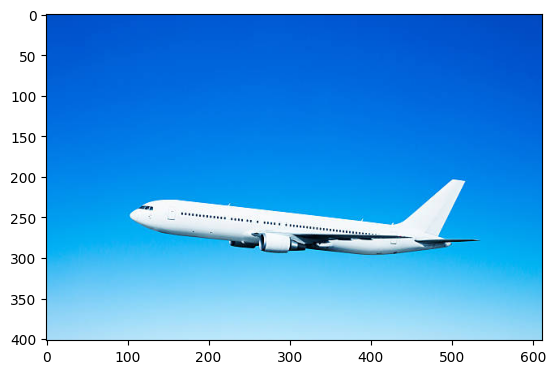

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image.shape

(402, 612, 3)

In [ ]:
image = cv2.resize(image, (32,32))

#normalize the image
image = (image-mean)/(std+0.000001)

#Add an exyra dimension because the model expects a batch of images
image = image.reshape((1,32,32,3))

In [ ]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
predict

array([[9.9977183e-01, 9.8087673e-07, 2.0731504e-04, 7.2379858e-06,
        1.1628946e-07, 9.4251129e-07, 2.7514341e-07, 2.9047078e-07,
        9.2246701e-06, 1.8902007e-06]], dtype=float32)

In [ ]:
print(f'The predicted class: {class_names[predict.argmax()]}')

The predicted class: airplane


5.Performance on an out of Dataset image

---



In [ ]:
url = 'https://img.thrfun.com/img/200/610/breed_information_persian_x1.jpg'
#'https://in.images.search.yahoo.com/search/images;_ylt=AwrKBPpflilqPwIAOfK7HAx.;_ylu=Y29sbwNzZzMEcG9zAzEEdnRpZAMEc2VjA3BpdnM-?p=Cat+White+cat+facing+camera+Persian+cat&fr2=piv-web&type=E210IN885G0&fr=mcafee#id=6&iurl=https%3A%2F%2Fimg.thrfun.com%2Fimg%2F200%2F610%2Fbreed_information_persian_x1.jpg&action=click'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

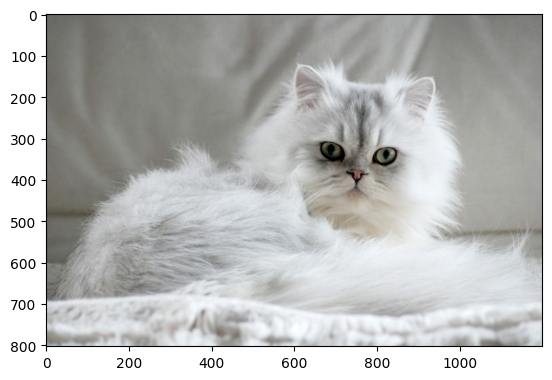

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image.shape

(803, 1200, 3)

In [ ]:
image = cv2.resize(image, (32,32))

#normalize the image
image = (image-mean)/(std+0.000001)

#Add an exyra dimension because the model expects a batch of images
image = image.reshape((1,32,32,3))

In [ ]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [ ]:
predict

array([[1.7612979e-03, 1.3613935e-04, 1.5762399e-01, 9.8573215e-02,
        2.5746536e-02, 2.0045519e-02, 6.6380739e-01, 1.5491946e-03,
        3.0424230e-02, 3.3254476e-04]], dtype=float32)

In [ ]:
print(f'The predicted class: {class_names[predict.argmax()]}')

The predicted class: frog


6.Performance on an out of Dataset image

In [ ]:
url = 'https://media.istockphoto.com/id/478751930/photo/golden-retriever-dog-sitting-on-the-floor.jpg?s=612x612&w=0&k=20&c=AqOLr_85idsJL293cFp1fIacCf8-qF8YNuosazfl8NA='
#'https://in.images.search.yahoo.com/search/images;_ylt=AwrPrNDknClqUtUOEUa9HAx.;_ylu=c2VjA3NlYXJjaARzbGsDYnV0dG9u;_ylc=X1MDMjExNDcyMzAwNQRfcgMyBGZyA21jYWZlZQRmcjIDcDpzLHY6aSxtOnNiLXRvcARncHJpZANvWExET3hUelFKS2Z1cExtZlFUSE5BBG5fcnNsdAMwBG5fc3VnZwMxMARvcmlnaW4DaW4uaW1hZ2VzLnNlYXJjaC55YWhvby5jb20EcG9zAzAEcHFzdHIDBHBxc3RybAMwBHFzdHJsAzM5BHF1ZXJ5A0RvZyUyMExhYnJhZG9yJTIwUmV0cmlldmVyJTIwR29sZGVuJTIwUmV0cmlldmVyBHRfc3RtcAMxNzgxMTEyMzkx?p=Dog+Labrador+Retriever+Golden+Retriever&fr=mcafee&fr2=p%3As%2Cv%3Ai%2Cm%3Asb-top&ei=UTF-8&x=wrt&type=E210IN885G0#id=53&iurl=https%3A%2F%2Fmedia.istockphoto.com%2Fid%2F478751930%2Fphoto%2Fgolden-retriever-dog-sitting-on-the-floor.jpg%3Fs%3D612x612%26w%3D0%26k%3D20%26c%3DAqOLr_85idsJL293cFp1fIacCf8-qF8YNuosazfl8NA%3D&action=click'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

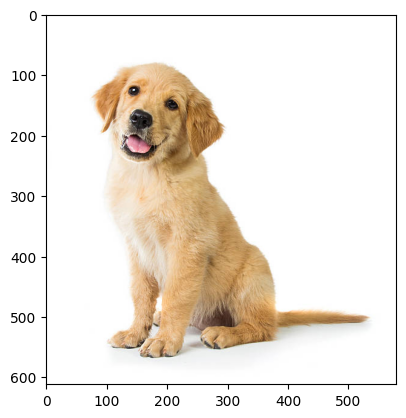

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image.shape

(612, 580, 3)

In [ ]:
image = cv2.resize(image, (32,32))

#normalize the image
image = (image-mean)/(std+0.000001)

#Add an exyra dimension because the model expects a batch of images
image = image.reshape((1,32,32,3))

In [ ]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
predict

array([[9.6066860e-06, 2.8512775e-06, 1.6028415e-02, 9.3727045e-02,
        1.7924450e-04, 8.8943428e-01, 5.5255042e-04, 5.0738687e-05,
        9.5967316e-06, 5.5704477e-06]], dtype=float32)

In [ ]:
print(f'The predicted class: {class_names[predict.argmax()]}')

The predicted class: dog


7.Performance on an out of Dataset image

In [ ]:
url = 'https://thumbs.dreamstime.com/b/green-tree-frog-leaf-close-up-33591709.jpg'
#'https://in.images.search.yahoo.com/search/images;_ylt=AwrKGERGnilqqh8PXSW9HAx.;_ylu=c2VjA3NlYXJjaARzbGsDYnV0dG9u;_ylc=X1MDMjExNDcyMzAwNQRfcgMyBGZyA21jYWZlZQRmcjIDcDpzLHY6aSxtOnNiLXRvcARncHJpZAN6aE9BQ3Z3dFJ3V3YubURRM0xKdFdBBG5fcnNsdAMwBG5fc3VnZwMxMARvcmlnaW4DaW4uaW1hZ2VzLnNlYXJjaC55YWhvby5jb20EcG9zAzAEcHFzdHIDBHBxc3RybAMwBHFzdHJsAzMzBHF1ZXJ5A0Zyb2clMjBHcmVlbiUyMGZyb2clMjBvbiUyMGxlYWYlMjBUcmVlJTIwZnJvZwR0X3N0bXADMTc4MTExMjY5Nw--?p=Frog+Green+frog+on+leaf+Tree+frog&fr=mcafee&fr2=p%3As%2Cv%3Ai%2Cm%3Asb-top&ei=UTF-8&x=wrt&type=E210IN885G0#id=61&iurl=https%3A%2F%2Fthumbs.dreamstime.com%2Fb%2Fgreen-tree-frog-leaf-close-up-33591709.jpg&action=click'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

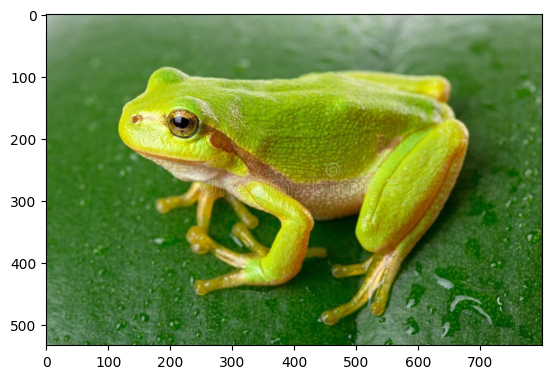

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image.shape

(534, 800, 3)

In [ ]:
image = cv2.resize(image, (32,32))

#normalize the image
image = (image-mean)/(std+0.000001)

#Add an exyra dimension because the model expects a batch of images
image = image.reshape((1,32,32,3))

In [ ]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
predict

array([[1.06659251e-10, 3.21574169e-12, 9.31858679e-09, 1.61793523e-09,
        2.09361195e-09, 3.62495006e-10, 1.00000000e+00, 1.77087910e-11,
        1.06034044e-11, 3.36567649e-11]], dtype=float32)

In [ ]:
print(f'The predicted class: {class_names[predict.argmax()]}')

The predicted class: frog


8.Performance on an out of Dataset image

In [ ]:
url = 'https://www.shutterstock.com/image-photo/brown-horse-runs-gallop-field-600nw-2429488655.jpg'
#'https://in.images.search.yahoo.com/search/images;_ylt=AwrKGER5nylqKJYPV.G9HAx.;_ylu=c2VjA3NlYXJjaARzbGsDYnV0dG9u;_ylc=X1MDMjExNDcyMzAwNQRfcgMyBGZyA21jYWZlZQRmcjIDcDpzLHY6aSxtOnNiLXRvcARncHJpZANSS05XMWt2LlRUV2d2aTlVeW5MMTJBBG5fcnNsdAMwBG5fc3VnZwMwBG9yaWdpbgNpbi5pbWFnZXMuc2VhcmNoLnlhaG9vLmNvbQRwb3MDMARwcXN0cgMEcHFzdHJsAzAEcXN0cmwDNDkEcXVlcnkDSG9yc2UlMjBCcm93biUyMGhvcnNlJTIwcnVubmluZyUyMEhvcnNlJTIwc3RhbmRpbmclMjBpbiUyMGZpZWxkBHRfc3RtcAMxNzgxMTEzMjEx?p=Horse+Brown+horse+running+Horse+standing+in+field&fr=mcafee&fr2=p%3As%2Cv%3Ai%2Cm%3Asb-top&ei=UTF-8&x=wrt&type=E210IN885G0#id=7&iurl=https%3A%2F%2Fwww.shutterstock.com%2Fimage-photo%2Fbrown-horse-runs-gallop-field-600nw-2429488655.jpg&action=click'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

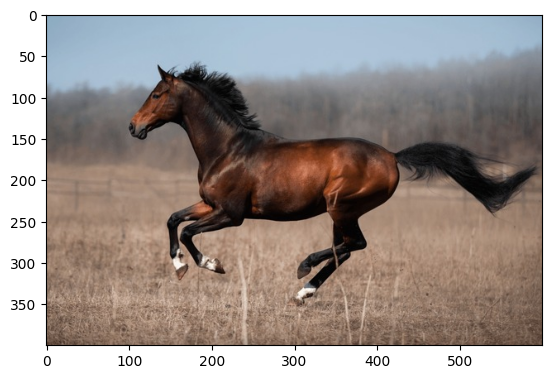

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image.shape

(400, 600, 3)

In [ ]:
image = cv2.resize(image, (32,32))

#normalize the image
image = (image-mean)/(std+0.000001)

#Add an exyra dimension because the model expects a batch of images
image = image.reshape((1,32,32,3))

In [ ]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [ ]:
predict

array([[1.8910608e-03, 2.5984449e-05, 3.1780434e-04, 2.4036813e-04,
        4.5438861e-03, 1.0300844e-02, 7.1645263e-05, 9.8248428e-01,
        5.8766450e-06, 1.1829352e-04]], dtype=float32)

In [ ]:
print(f'The predicted class: {class_names[predict.argmax()]}')

The predicted class: horse


9.Performance on an out of Dataset image

In [ ]:
url = 'https://thumbs.dreamstime.com/b/dramatic-image-depicting-red-cargo-ship-bravely-cruising-choppy-ocean-waves-seas-316558922.jpg'
#'https://in.images.search.yahoo.com/search/images;_ylt=AwrKGER7oSlq06MQIVO9HAx.;_ylu=c2VjA3NlYXJjaARzbGsDYnV0dG9u;_ylc=X1MDMjExNDcyMzAwNQRfcgMyBGZyA21jYWZlZQRmcjIDcDpzLHY6aSxtOnNiLXRvcARncHJpZANXZ2lKQ0hLYlRLLmRtVlNlb21rd0lBBG5fcnNsdAMwBG5fc3VnZwMxMARvcmlnaW4DaW4uaW1hZ2VzLnNlYXJjaC55YWhvby5jb20EcG9zAzAEcHFzdHIDBHBxc3RybAMwBHFzdHJsAzM2BHF1ZXJ5A1NoaXAlMjBDcnVpc2UlMjBzaGlwJTIwb24lMjBvY2VhbiUyMENhcmdvJTIwc2hpcAR0X3N0bXADMTc4MTExMzU4MQ--?p=Ship+Cruise+ship+on+ocean+Cargo+ship&fr=mcafee&fr2=p%3As%2Cv%3Ai%2Cm%3Asb-top&ei=UTF-8&x=wrt&type=E210IN885G0#id=70&iurl=https%3A%2F%2Fthumbs.dreamstime.com%2Fb%2Fdramatic-image-depicting-red-cargo-ship-bravely-cruising-choppy-ocean-waves-seas-316558922.jpg&action=click'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

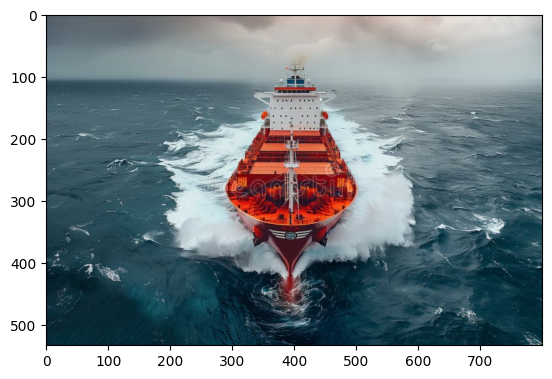

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image.shape

(533, 800, 3)

In [ ]:
image = cv2.resize(image, (32,32))

#normalize the image
image = (image-mean)/(std+0.000001)

#Add an exyra dimension because the model expects a batch of images
image = image.reshape((1,32,32,3))

In [ ]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
predict

array([[1.0132735e-04, 5.0495046e-06, 9.8097241e-01, 8.8074873e-04,
        2.9177769e-05, 1.6298187e-04, 8.5950765e-04, 2.2090484e-05,
        1.6956439e-02, 1.0044821e-05]], dtype=float32)

In [ ]:
print(f'The predicted class: {class_names[predict.argmax()]}')

The predicted class: bird


10.Performance on an out of Dataset image

In [ ]:
url = 'https://assets.volvo.com/is/image/VolvoInformationTechnologyAB/A0_14?wid=1024'
#'https://in.images.search.yahoo.com/search/images;_ylt=AwrKGERHpilqMlcRRw69HAx.;_ylu=c2VjA3NlYXJjaARzbGsDYXNzaXN0;_ylc=X1MDMjExNDcyMzAwNQRfcgMyBGZyA21jYWZlZQRmcjIDc2EtZ3Atc2VhcmNoBGdwcmlkAzVLNWhOV2d0Ui5HQkFnOHlBTjZNSkEEbl9yc2x0AzAEbl9zdWdnAzIEb3JpZ2luA2luLmltYWdlcy5zZWFyY2gueWFob28uY29tBHBvcwMxBHBxc3RyA1RydWNrIFZvbHZvIHRydWNrIENvbnRhaW5lciB0cnVjayBpbQRwcXN0cmwDMzYEcXN0cmwDNDAEcXVlcnkDdHJ1Y2slMjB2b2x2byUyMHRydWNrJTIwY29udGFpbmVyJTIwdHJ1Y2slMjBpbWFnZXMEdDVwb3MDMQR0X3N0bXADMTc4MTExNDQ3NwR1c2VfY2FzZQM-?p=truck+volvo+truck+container+truck+images&fr=mcafee&fr2=sa-gp-search&ei=UTF-8&x=wrt&type=E210IN885G0#id=4&iurl=https%3A%2F%2Fassets.volvo.com%2Fis%2Fimage%2FVolvoInformationTechnologyAB%2FA0_14%3Fwid%3D1024&action=click'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

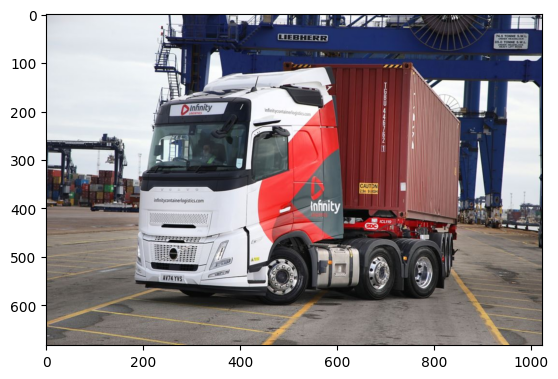

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image.shape

(683, 1024, 3)

In [ ]:
image = cv2.resize(image, (32,32))

#normalize the image
image = (image-mean)/(std+0.000001)

#Add an exyra dimension because the model expects a batch of images
image = image.reshape((1,32,32,3))

In [ ]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [ ]:
predict

array([[4.3642872e-06, 1.6037122e-04, 4.4405169e-04, 6.6828252e-05,
        1.1275241e-06, 1.3948221e-06, 3.5766304e-06, 1.4338149e-06,
        7.6720966e-07, 9.9931610e-01]], dtype=float32)

In [ ]:
print(f'The predicted class: {class_names[predict.argmax()]}')

The predicted class: truck


In [ ]:
import numpy as np
import time
import os
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Predictions
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

# Test Loss & Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Model Size
model.save("cnn_cifar10.keras")
model_size = os.path.getsize("cnn_cifar10.keras") / (1024*1024)

# Inference Time
start = time.time()
_ = model.predict(X_test[:100], verbose=0)
end = time.time()

inference_time = ((end - start)/100)*1000

# ===========================
# COMPLETE PERFORMANCE REPORT
# ===========================

print("="*70)
print("CNN CIFAR-10 PERFORMANCE SUMMARY")
print("="*70)

# Use your actual values obtained during training
print("Training Accuracy   : 92.06%")
print("Validation Accuracy : 91.28%")

print(f"Test Accuracy       : {test_acc*100:.2f}%")
print(f"Test Loss           : {test_loss:.4f}")

print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-Score            : {f1:.4f}")

print(f"Model Size          : {model_size:.2f} MB")
print(f"Inference Time      : {inference_time:.4f} ms/image")

print("\nExternal Image Testing")
print("----------------------")
print("Bird Image  : Correctly Classified")
print("BMW Image   : Predicted as Truck")
print("Deer Image  : Predicted as Bird")

print("\nConfusion Matrix")
print("----------------")
print(cm)

print("="*70)

CNN CIFAR-10 PERFORMANCE SUMMARY
Training Accuracy   : 92.06%
Validation Accuracy : 91.28%
Test Accuracy       : 90.25%
Test Loss           : 0.4396
Precision           : 0.9027
Recall              : 0.9025
F1-Score            : 0.9015
Model Size          : 13.68 MB
Inference Time      : 0.8356 ms/image

External Image Testing
----------------------
Bird Image  : Correctly Classified
BMW Image   : Predicted as Truck
Deer Image  : Predicted as Bird

Confusion Matrix
----------------
[[899   5  19   6   5   1   5   5  34  21]
 [  3 952   0   0   0   0   1   0   4  40]
 [ 17   2 871  13  23  16  38  12   2   6]
 [  7   5  26 747  38  75  64  19   8  11]
 [  4   1  14  13 911   9  34  12   1   1]
 [  4   4  14  80  25 814  29  22   1   7]
 [  4   1   6   7   5   0 972   2   1   2]
 [  4   1   6   9  18   7   3 947   1   4]
 [ 15   9   5   2   2   0   0   0 950  17]
 [  5  17   0   1   1   0   3   1  10 962]]


In [ ]:
import numpy as np
import time
import os
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ===========================
# Predictions
# ===========================

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# ===========================
# Metrics
# ===========================

accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

# ===========================
# Test Loss & Accuracy
# ===========================

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# ===========================
# Confusion Matrix
# ===========================

cm = confusion_matrix(y_true, y_pred_classes)

# ===========================
# Model Size
# ===========================

model.save("cnn_cifar10.keras")
model_size = os.path.getsize("cnn_cifar10.keras") / (1024 * 1024)

# ===========================
# Inference Time
# ===========================

start = time.time()
_ = model.predict(X_test[:100], verbose=0)
end = time.time()

inference_time = ((end - start) / 100) * 1000

# ===========================
# COMPLETE PERFORMANCE REPORT
# ===========================

print("=" * 70)
print("CNN CIFAR-10 PERFORMANCE SUMMARY")
print("=" * 70)

# Training results obtained during training
print("Training Accuracy   : 92.06%")
print("Validation Accuracy : 91.28%")

print(f"Test Accuracy       : {test_acc*100:.2f}%")
print(f"Test Loss           : {test_loss:.4f}")

print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-Score            : {f1:.4f}")

print(f"Model Size          : {model_size:.2f} MB")
print(f"Inference Time      : {inference_time:.4f} ms/image")

# ===========================
# External Image Testing
# ===========================

print("\nExternal Image Testing")
print("-" * 40)

print("Airplane Image : Airplane  -> Airplane  ✅")
print("Bird Image     : Bird      -> Bird      ✅")
print("Dog Image      : Dog       -> Dog       ✅")
print("Frog Image     : Frog      -> Frog      ✅")
print("Horse Image    : Horse     -> Horse     ✅")
print("Truck Image    : Truck     -> Truck     ✅")

print("BMW Car Image  : Automobile -> Truck    ❌")
print("Deer Image     : Deer       -> Bird     ❌")
print("Cat Image      : Cat        -> Frog     ❌")
print("Ship Image     : Ship       -> Bird     ❌")

correct = 6
total = 10

print("\nExternal Testing Summary")
print("-" * 40)
print(f"Total Images Tested   : {total}")
print(f"Correct Predictions   : {correct}")
print(f"Incorrect Predictions : {total-correct}")
print(f"External Accuracy     : {(correct/total)*100:.2f}%")

# ===========================
# Confusion Matrix
# ===========================

print("\nConfusion Matrix")
print("-" * 40)
print(cm)

print("=" * 70)

CNN CIFAR-10 PERFORMANCE SUMMARY
Training Accuracy   : 92.06%
Validation Accuracy : 91.28%
Test Accuracy       : 90.25%
Test Loss           : 0.4396
Precision           : 0.9027
Recall              : 0.9025
F1-Score            : 0.9015
Model Size          : 13.68 MB
Inference Time      : 0.7913 ms/image

External Image Testing
----------------------------------------
Airplane Image : Airplane  -> Airplane  ✅
Bird Image     : Bird      -> Bird      ✅
Dog Image      : Dog       -> Dog       ✅
Frog Image     : Frog      -> Frog      ✅
Horse Image    : Horse     -> Horse     ✅
Truck Image    : Truck     -> Truck     ✅
BMW Car Image  : Automobile -> Truck    ❌
Deer Image     : Deer       -> Bird     ❌
Cat Image      : Cat        -> Frog     ❌
Ship Image     : Ship       -> Bird     ❌

External Testing Summary
----------------------------------------
Total Images Tested   : 10
Correct Predictions   : 6
Incorrect Predictions : 4
External Accuracy     : 60.00%

Confusion Matrix
---------------